In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Raw data access

import os
os.chdir('/content/drive/MyDrive/MPXV_pycaret')

#### **Importing the modules** ####

In [4]:
from glob import glob
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [5]:
ls


 11_micro_marker.csv     6_MPXV_Marker_Prediction_Using_Classification_Pycrate.ipynb
 14_clade_IIb_pROC.csv  'Copy of DenguePrediction_Using_Regression_Pycrate.ipynb'
 24_clade_IIb_pROC.csv   logs.log
 28_clade_IIb_pROC.csv   MPXV_Marker_Prediction_Using_Classification_Pycrate.ipynb
 6_micro_marker.csv


#### **Load Dataset** ####

In [6]:
MPXV_df = pd.read_csv("6_micro_marker.csv", index_col=0)


In [7]:
display(MPXV_df.head(3))


,PLEKHM2,CCN1,SPATA2,C1S,PCBP2,MLX,group
GSM283173,-0.642410,-3.804237,-2.502960,0.683763,-1.507359,-0.613796,0
GSM283177,-1.115440,-2.902096,-2.502079,2.022584,-0.683948,-0.405042,0
GSM283187,-1.144704,-2.955126,-2.776867,2.048971,-0.843383,-0.270373,0


#### **Data Preprocessing** ####
##### **Checking null entries** #####

In [8]:
MPXV_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48 entries, GSM283173 to GSM593985
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   PLEKHM2  48 non-null     float64
 1   CCN1     48 non-null     float64
 2   SPATA2   48 non-null     float64
 3   C1S      48 non-null     float64
 4   PCBP2    48 non-null     float64
 5   MLX      48 non-null     float64
 6   group    48 non-null     int64  
dtypes: float64(6), int64(1)
memory usage: 3.0+ KB


In [ ]:
# Checking columns having null values
#MPXV_df.isna().sum()

In [ ]:
# Getting the list of columns having missing values
#x = dengue_features.columns[dengue_features.isna().sum() > 0].tolist()
#x

In [ ]:
# Filling the missing value with mean
#for i in x:
#    dengue_features[i] = dengue_features[i].fillna(dengue_features[i].mean())
#dengue_features.head()

##### **merge dataset** #####

In [ ]:
# Adding total cases
#dengue_features['total_cases'] = dengue_labels['total_cases']
#dengue_features.head(3)

##### **Feature Engineering** #####
The dengue cases of San Juan sj and Iquitos iq are not dependent. So splitting them into different DataFrames

In [ ]:
#X_sj = dengue_features[dengue_features['city'] == 'sj']
#X_iq = dengue_features[dengue_features['city'] == 'iq']

In [ ]:
# MPXV_df = MPXV_df.drop(['condition'], axis=1)
#X_iq = X_iq.drop(['city', 'weekofyear', 'week_start_date'], axis=1)

In [ ]:
# display(MPXV_df.head(2))
#display(X_iq.head(2))

In [ ]:
#display(X_sj.head(2))
#display(X_iq.head(2))

##### **Changing the order of columns in X_sj and X_iq DataFrames** #####

In [ ]:
# X_sj.columns

In [ ]:
# X_sj_1 = X_sj.columns[-3:].values.tolist()
# X_sj_2 = X_sj.columns[:15].values.tolist()

In [ ]:
# print(X_sj_1)

In [ ]:
# years = X_sj_1 + X_sj_2
# print(years)

In [ ]:
# X_sj = X_sj[years[::-1]].join(X_sj[X_sj.columns[:24]])
# X_sj.head(100)

In [ ]:
# years = X_iq.columns[:23:-1].values.tolist()
# print(years)
# X_iq = X_iq[years[::-1]].join(X_iq[X_iq.columns[:24]])
# X_iq.head()

In [ ]:
# Removing dummy variable trap
# X_sj = X_sj.drop(1990, axis=1)
# X_iq = X_iq.drop(2000, axis=1)

In [ ]:
# x_sj_arr = X_sj.iloc[:].values
# x_iq_arr = X_iq.iloc[:].values

In [ ]:
# y_sj = X_sj['total_cases'].values
# y_iq = X_iq['total_cases'].values

In [ ]:
# X_sj = X_sj.drop('total_cases', axis=1).values
# X_iq = X_iq.drop('total_cases', axis=1).values

#### **Splitting the dataframes into train and test** ####

In [9]:
!pip install pycaret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.1/486.1 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 8.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 34.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.0/165.0 kB 17.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.3/258.3 kB 26.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.9/81.9 kB 10.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 21.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 13.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 9.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 43.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5

In [48]:
# import pycaret classification and init setup
from pycaret.classification import *
setup(MPXV_df, target = 'group', train_size = 0.8, session_id = 123)
# setup(X_iq, target = 'total_cases', train_size = 0.8, session_id = 123)

,Description,Value
0,Session id,123
1,Target,group
2,Target type,Binary
3,Original data shape,"(48, 7)"
4,Transformed data shape,"(48, 7)"
5,Transformed train set shape,"(38, 7)"
6,Transformed test set shape,"(10, 7)"
7,Numeric features,6
8,Preprocess,True
9,Imputation type,simple


## **Compare Models** ##

In [49]:
# compare baseline models
best = compare_models()
print(best)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.1660
nb,Naive Bayes,0.9750,1.0000,1.0000,0.9500,0.9667,0.9500,0.9577,0.0560
dt,Decision Tree Classifier,0.9750,0.9833,1.0000,0.9500,0.9667,0.9500,0.9577,0.0620
rf,Random Forest Classifier,0.9750,1.0000,1.0000,0.9500,0.9667,0.9500,0.9577,0.2800
ada,Ada Boost Classifier,0.9750,1.0000,1.0000,0.9500,0.9667,0.9500,0.9577,0.1310
gbc,Gradient Boosting Classifier,0.9750,1.0000,1.0000,0.9500,0.9667,0.9500,0.9577,0.1040
xgboost,Extreme Gradient Boosting,0.9750,1.0000,1.0000,0.9500,0.9667,0.9500,0.9577,0.0510
lr,Logistic Regression,0.9500,1.0000,0.9500,0.9500,0.9333,0.9000,0.9155,0.0640
svm,SVM - Linear Kernel,0.9500,1.0000,0.9500,0.9500,0.9333,0.9000,0.9155,0.0490
ridge,Ridge Classifier,0.9500,1.0000,0.9500,0.9500,0.9333,0.9000,0.9155,0.0650


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                     criterion='gini', max_depth=None, max_features='sqrt',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_samples_leaf=1,
                     min_samples_split=2, min_weight_fraction_leaf=0.0,
                     monotonic_cst=None, n_estimators=100, n_jobs=-1,
                     oob_score=False, random_state=123, verbose=0,
                     warm_start=False)


## **Create Model**##

In [50]:
# create model
rf = create_model('rf')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,0.7500,1.0000,1.0000,0.5000,0.6667,0.5000,0.5774
4,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
5,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
6,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [51]:
# print model parameters
print(rf)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=123, verbose=0,
                       warm_start=False)


## **Tune Model** ##

In [52]:
# tune hyperparameters of et
tuned_rf = tune_model(rf)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,0.7500,1.0000,1.0000,0.5000,0.6667,0.5000,0.5774
4,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
5,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
6,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [53]:
# print tuned model
print(tuned_rf)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=123, verbose=0,
                       warm_start=False)


In [54]:
tuned_rf

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=123, verbose=0,
                       warm_start=False)

In [55]:
# to access the tuner object you can set return_tuner = True
tuned_rf, tuner = tune_model(rf, return_tuner=True)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,0.7500,1.0000,1.0000,0.5000,0.6667,0.5000,0.5774
4,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
5,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
6,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [56]:
tuner

RandomizedSearchCV(cv=StratifiedKFold(n_splits=10, random_state=None, shuffle=False),
                   error_score=nan,
                   estimator=Pipeline(memory=Memory(location=None),
                                      steps=[('numerical_imputer',
                                              TransformerWrapper(exclude=None,
                                                                 include=['PLEKHM2',
                                                                          'CCN1',
                                                                          'SPATA2',
                                                                          'C1S',
                                                                          'PCBP2',
                                                                          'MLX'],
                                                                 transformer=SimpleImputer(add_indicator=False,
                                                                                           copy=True,
                                                                                           fill_value=None,
                                                                                           keep_empty_feat...
                                        'actual_estimator__min_samples_leaf': [2,
                                                                               3,
                                                                               4,
                                                                               5,
                                                                               6],
                                        'actual_estimator__min_samples_split': [2,
                                                                                5,
                                                                                7,
                                                                                9,
                                                                                10],
                                        'actual_estimator__n_estimators': [10,
                                                                           20,
                                                                           30,
                                                                           40,
                                                                           50,
                                                                           60,
                                                                           70,
                                                                           80,
                                                                           90,
                                                                           100,
                                                                           110,
                                                                           120,
                                                                           130,
                                                                           140,
                                                                           150,
                                                                           160,
                                                                           170,
                                                                           180,
                                                                           190,
                                                                           200,
                                                                           210,
                                                                           220,
                                                                           230,
                                                                           2

## **Analyze Model** ##

In [57]:
plot_model(rf, plot = 'residuals')

ValueError: Plot Not Available. Please see docstring for list of available Plots.

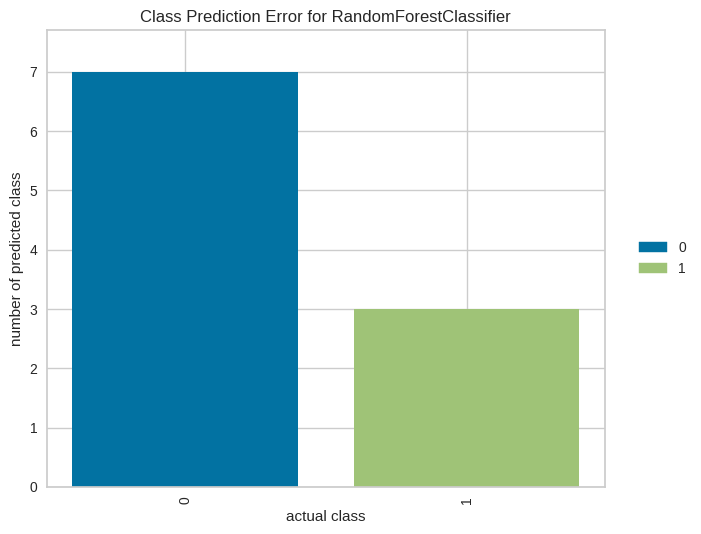

In [58]:
# predicting error plot
plot_model(rf, plot = 'error')

In [59]:
# cooks distance plot
plot_model(rf, plot = 'cooks')

ValueError: Plot Not Available. Please see docstring for list of available Plots.

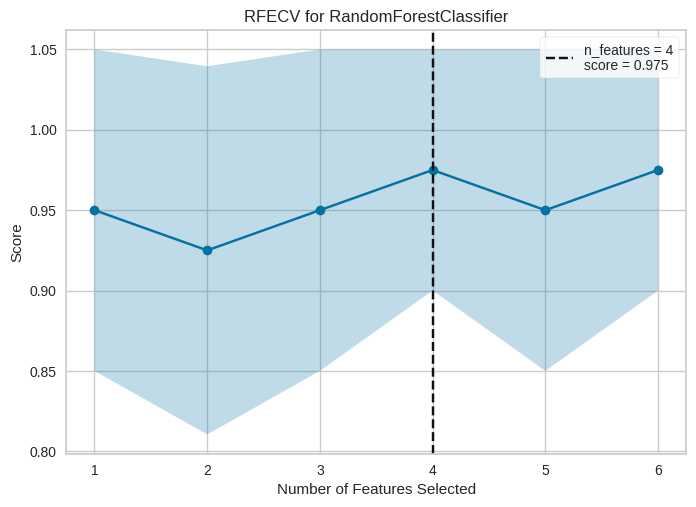

In [60]:
# recursive feature elemination
plot_model(rf, plot = 'rfe')

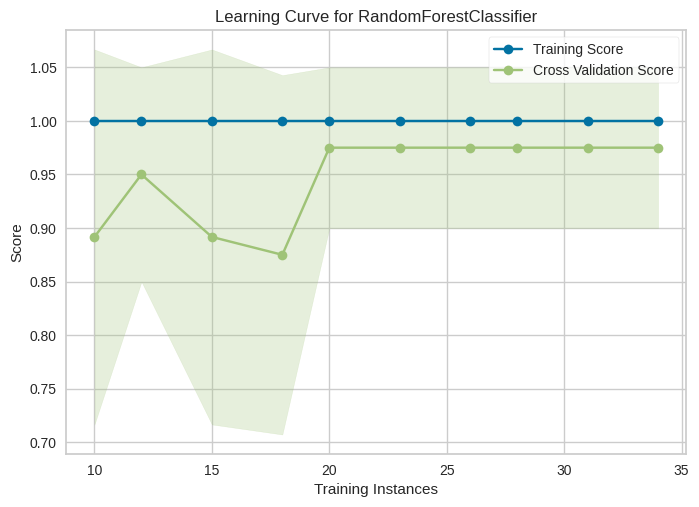

In [61]:
# learning curve
plot_model(rf, plot = 'learning')

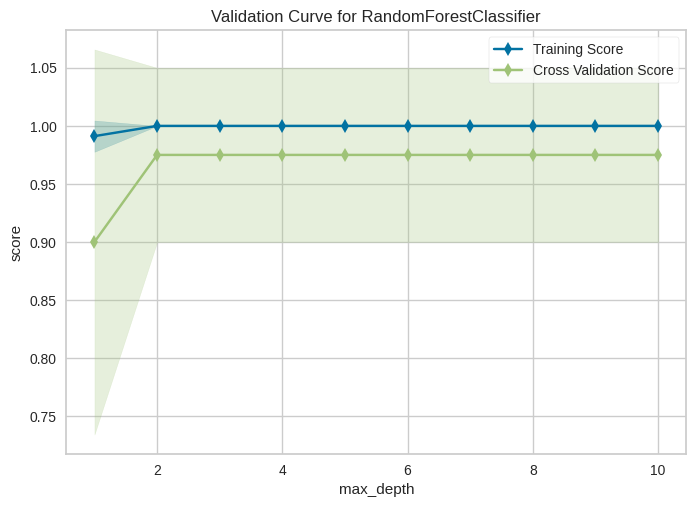

In [62]:
# validation curve
plot_model(rf, plot = 'vc')

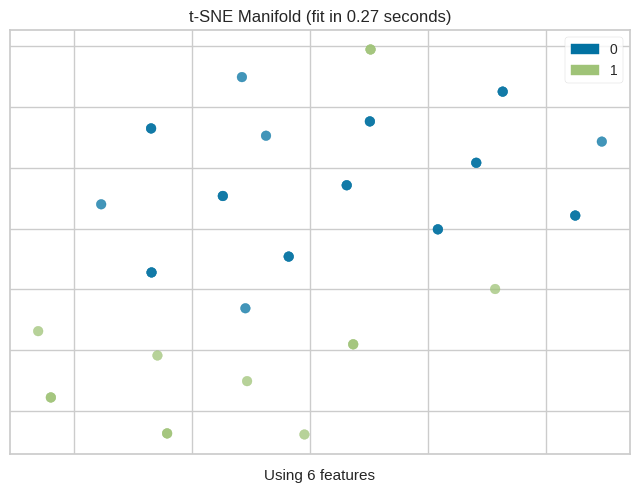

In [63]:
# manifold learning plot
plot_model(rf, plot = 'manifold')

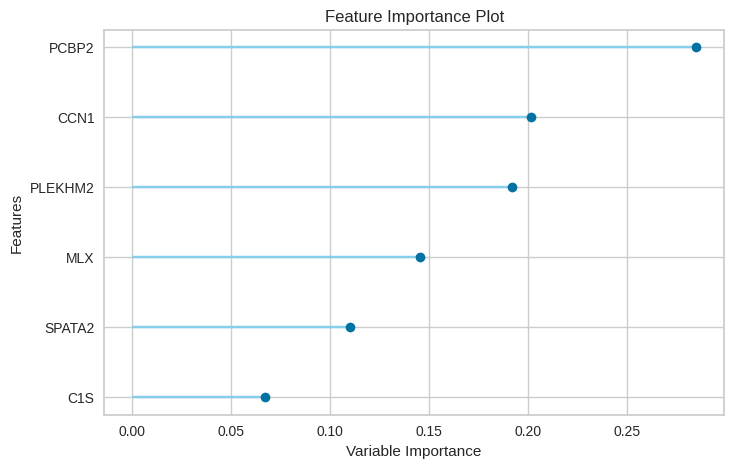

In [65]:
# plot feature importance
plot_model(rf, plot = 'feature')

## **Evaluate Model** ##

In [ ]:
# evaluate model
evaluate_model(rf)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

## **Finalize Model** ##

In [ ]:
# finalize a model
finalize_model(rf)

Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['WDR37', 'NFAT5', 'ICAM5', 'ELL',
                                             'PLAGL1', 'DHX38', 'GATA6',
                                             'ZNF212', 'CBX6', 'ATP5MG',
                                             'GM2A'],
                                    transformer=SimpleImputer(add_indicator=False,
                                                              copy=True,
                                                              fill_value=None,
                                                              keep_empty_features=False,
                                                              missing_values=nan,
                                                              strategy='mean'))),
                ('categorical_imput...
                 RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                        class_weight=None, criterion='gini',
                                        max_depth=None, max_features='sqrt',
                                        max_leaf_nodes=None, max_samples=None,
                                        min_impurity_decrease=0.0,
                                        min_samples_leaf=1, min_samples_split=2,
                                        min_weight_fraction_leaf=0.0,
                                        monotonic_cst=None, n_estimators=100,
                                        n_jobs=-1, oob_score=False,
                                        random_state=123, verbose=0,
                                        warm_start=False))],
         verbose=False)

In [ ]:
import pycaret
print(pycaret.__version__)


ModuleNotFoundError: No module named 'pycaret'

## **Prediction** ##

In [ ]:
# predict on test set
holdout_pred = predict_model(rf)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
